In [25]:
import numpy as np
import pandas as pd
import re
from pathlib import Path
from datetime import datetime
import matplotlib.pyplot as plt

In [ ]:
g = 9.81
rho = 1025.0

_float_re = re.compile(r"[-+]?\d*\.\d+(?:[Ee][-+]?\d+)?|[-+]?\d+(?:[Ee][-+]?\d+)?")
_int_re   = re.compile(r"[-+]?\d+")

def _floats_in_line(s):
    return [float(x) for x in _float_re.findall(s)]

def _ints_in_line(s):
    return [int(x) for x in _int_re.findall(s)]

def _parse_time_token(tok):
    """
    SWAN times here look like YYYYMMDD.HHMMSS with HHMMSS as fractional day digits in your example:
      20240925.003000  -> 2024-09-25 00:30:00  (i.e., 003000 = HHMMSS)
    """
    tok = tok.strip()
    # try exact "YYYYMMDD.HHMMSS"
    if re.match(r"^\d{8}\.\d{6}$", tok):
        return datetime.strptime(tok, "%Y%m%d.%H%M%S")
    # fallback: try YYYYMMDD
    if re.match(r"^\d{8}$", tok):
        return datetime.strptime(tok, "%Y%m%d")
    return None

def read_swan_spec_vadens_factor(spec_path):
    """
    Reads SWAN spectral file with:
      - AFREQ (nf)
      - CDIR (nd)
      - TIME records via QUANT/VaDens + date-time line + FACTOR + integer matrix (nf*nd)
    Returns dict: lon, lat, freqs, dirs (deg), times (list), E (nt,nf,nd) in m^2/Hz/rad
    """
    spec_path = Path(spec_path)
    lines = spec_path.read_text(errors="ignore").splitlines()

    # --- LONLAT (assumes 1 location) ---
    lon = lat = None
    for i, ln in enumerate(lines):
        if ln.strip().startswith("LONLAT"):
            nloc = int(lines[i+1].split()[0])
            if nloc != 1:
                raise ValueError(f"{spec_path.name}: expected 1 location, got {nloc}")
            lon, lat = _floats_in_line(lines[i+2])[:2]
            break
    if lon is None:
        raise ValueError(f"{spec_path.name}: LONLAT not found")

    # --- AFREQ ---
    freqs = None
    for i, ln in enumerate(lines):
        if ln.strip().startswith("AFREQ"):
            nf = int(lines[i+1].split()[0])
            vals = []
            j = i + 2
            while len(vals) < nf and j < len(lines):
                vals.extend(_floats_in_line(lines[j]))
                j += 1
            freqs = np.array(vals[:nf], dtype=float)
            break
    if freqs is None:
        raise ValueError(f"{spec_path.name}: AFREQ not found")
    nf = freqs.size

    # --- CDIR ---
    dirs = None
    for i, ln in enumerate(lines):
        if ln.strip().startswith("CDIR"):
            nd = int(lines[i+1].split()[0])
            vals = []
            j = i + 2
            while len(vals) < nd and j < len(lines):
                vals.extend(_floats_in_line(lines[j]))
                j += 1
            dirs = np.array(vals[:nd], dtype=float)
            break
    if dirs is None:
        raise ValueError(f"{spec_path.name}: CDIR not found")
    nd = dirs.size

    # --- TIME records (VaDens / FACTOR / integer table) ---
    times = []
    E_list = []

    i = 0
    while i < len(lines):
        ln = lines[i].strip()

        # We key off the VaDens block, since that's where the time+factor+matrix lives
        if ln.startswith("VaDens"):
            # scan forward for the time stamp line (first token parseable)
            t = None
            j = i
            while j < len(lines) and t is None:
                tok = lines[j].strip().split()[0] if lines[j].strip() else ""
                t = _parse_time_token(tok)
                j += 1
            if t is None:
                i += 1
                continue

            # scan forward for FACTOR
            k = j
            while k < len(lines) and not lines[k].strip().startswith("FACTOR"):
                k += 1
            if k >= len(lines):
                break

            factor = float(_floats_in_line(lines[k+1].strip())[0])

            # after factor line, read integers until we have nf*nd values
            vals = []
            m = k + 2
            while m < len(lines) and len(vals) < nf*nd:
                s = lines[m].strip()
                # stop if we hit the next time stamp (but only after we have enough)
                if re.match(r"^\d{8}\.\d{6}$", s.split()[0]) and len(vals) >= nf*nd:
                    break
                # skip labels
                if s == "" or s.startswith("$") or s.startswith("QUANT") or s.startswith("VaDens") or s.startswith("FACTOR"):
                    m += 1
                    continue
                vals.extend(_ints_in_line(s))
                m += 1

            if len(vals) < nf*nd:
                # incomplete record
                i = m
                continue

            A = np.array(vals[:nf*nd], dtype=float).reshape((nf, nd))
            E_deg = factor * A  # m^2/Hz/deg

            # Convert from per-degree to per-radian for physically correct ∫ E dθ:
            #   E_rad = E_deg * (deg per rad) = E_deg * (180/pi)
            E_rad = E_deg * (180.0 / np.pi)

            times.append(t)
            E_list.append(E_rad)

            i = m
        else:
            i += 1

    if len(times) == 0:
        raise ValueError(f"{spec_path.name}: no VaDens/FACTOR records found")

    E = np.stack(E_list, axis=0)  # (nt, nf, nd), m^2/Hz/rad

    return dict(lon=lon, lat=lat, freqs=freqs, dirs=dirs, times=times, E=E)

In [2]:
def hm0_from_E2d(freqs_hz, dirs_deg, E_tfd_rad):
    """
    E_tfd_rad is m^2/Hz/rad, shape (nt,nf,nd)
    """
    f = np.asarray(freqs_hz)
    th = np.deg2rad(np.asarray(dirs_deg))  # radians

    df = np.gradient(f)          # Hz
    dth = np.gradient(th)        # rad

    m0 = np.sum(E_tfd_rad * df[None,:,None] * dth[None,None,:], axis=(1,2))
    Hm0 = 4.0 * np.sqrt(m0)
    return Hm0, m0

def shoreward_flux_from_E2d(freqs_hz, dirs_deg, E_tfd_rad, shore_normal_toward_deg,
                            assume_dirs_are="to"):
    """
    Deep-water energy flux vector:
      F = ρ g ∫∫ Cg(f) E(f,θ) [unit_dir(θ)] df dθ
    with Cg = g/(4πf)

    dirs_deg: CDIR directions (deg clockwise from north)
    assume_dirs_are: "to" or "from"  (if "from", we rotate +180)
    shore_normal_toward_deg: azimuth (deg clockwise from north) pointing shoreward

    Returns: Fshore, Fx_east, Fy_north (W/m), each shape (nt,)
    """
    f = np.asarray(freqs_hz)
    dirs = np.asarray(dirs_deg)

    if assume_dirs_are.lower() == "from":
        dirs = (dirs + 180.0) % 360.0

    theta = np.deg2rad(dirs)  # radians, clockwise from north

    # Deep-water group velocity
    Cg = g / (4.0 * np.pi * f)  # m/s

    df = np.gradient(f)
    dth = np.gradient(theta)

    # unit vector in EN for azimuth theta (clockwise from north)
    ex = np.sin(theta)  # east component
    ny = np.cos(theta)  # north component

    W = (rho * g) * (Cg * df)  # (nf,)

    Fx = np.sum(E_tfd_rad * W[None,:,None] * dth[None,None,:] * ex[None,None,:], axis=(1,2))
    Fy = np.sum(E_tfd_rad * W[None,:,None] * dth[None,None,:] * ny[None,None,:], axis=(1,2))

    alpha = np.deg2rad(shore_normal_toward_deg)
    ux = np.sin(alpha)
    uy = np.cos(alpha)

    Fshore = Fx * ux + Fy * uy
    return Fshore, Fx, Fy


In [3]:
def haversine_km(lon1, lat1, lon2, lat2):
    R = 6371.0
    lam1, phi1, lam2, phi2 = map(np.deg2rad, [lon1, lat1, lon2, lat2])
    dlam = lam2 - lam1
    dphi = phi2 - phi1
    a = np.sin(dphi/2)**2 + np.cos(phi1)*np.cos(phi2)*np.sin(dlam/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

def cumulative_distance_km(lons, lats):
    s = np.zeros(len(lons))
    for i in range(1, len(lons)):
        s[i] = s[i-1] + haversine_km(lons[i-1], lats[i-1], lons[i], lats[i])
    return s

def curtain_plot(lons, lats, times, Fshore_2d, title="Shoreward wave energy flux curtain"):
    """
    Fshore_2d shape (nloc, nt)
    """
    from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

    s_km = cumulative_distance_km(lons, lats)
    nloc, nt = Fshore_2d.shape
    z = np.arange(nt)

    fig = plt.figure(figsize=(11, 7))
    ax = fig.add_subplot(111, projection="3d")

    for i in range(nloc):
        xvals = np.full(nt, s_km[i])
        yvals = np.zeros(nt)
        sc = ax.scatter(xvals, yvals, z, c=Fshore_2d[i, :], s=30)

    ax.set_xlabel("Distance along track (km)")
    ax.set_ylabel("")
    ax.set_yticks([])

    # label a few times
    nlab = 6
    zticks = np.linspace(0, nt-1, nlab).astype(int)
    ax.set_zticks(zticks)
    ax.set_zticklabels([times[k].strftime("%Y-%m-%d\n%H:%M") for k in zticks])
    ax.zaxis.set_tick_params(pad=12)

    ax.set_title(title)
    cbar = plt.colorbar(sc, ax=ax, shrink=0.7, pad=0.08)
    cbar.set_label("Shoreward wave energy flux (W m$^{-1}$)")

    ax.view_init(elev=28, azim=245)
    plt.show()


In [26]:
# -------------------------
# Read contour file
# -------------------------
contour_file = 'contour30sp.csv'
df = pd.read_csv(contour_file)

contour30sp = np.column_stack((df['contour30s_lon'], df['contour30s_lat']))
normals30sp = np.column_stack((df['normals30_x'], df['normals30_y']))   # already normalized (unit)
xy30sp      = np.column_stack((df['contour30s_x'],  df['contour30s_y']))

# -------------------------
# Helpers
# -------------------------
_float_re = re.compile(r"[-+]?\d*\.\d+(?:[Ee][-+]?\d+)?|[-+]?\d+(?:[Ee][-+]?\d+)?")

def _floats_in_line(s):
    return [float(x) for x in _float_re.findall(s)]

def haversine_m(lon1, lat1, lon2, lat2):
    """
    Great-circle distance in meters.
    lon2/lat2 can be arrays.
    """
    R = 6371000.0
    lon1 = np.deg2rad(lon1)
    lat1 = np.deg2rad(lat1)
    lon2 = np.deg2rad(lon2)
    lat2 = np.deg2rad(lat2)

    dlon = lon2 - lon1
    dlat = lat2 - lat1

    a = np.sin(dlat/2.0)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2.0)**2
    return 2.0 * R * np.arcsin(np.sqrt(a))

def read_swan_lonlat_only(spc_path):
    """
    Read only the LONLAT block from a SWAN .spc/.spec file.
    Assumes number of locations = 1.
    """
    lines = Path(spc_path).read_text(errors="ignore").splitlines()
    for i, ln in enumerate(lines):
        if ln.strip().startswith("LONLAT"):
            nloc = int(lines[i+1].split()[0])
            if nloc != 1:
                raise ValueError(f"{Path(spc_path).name}: expected 1 location, got {nloc}")
            lon, lat = _floats_in_line(lines[i+2])[:2]
            return lon, lat
    raise ValueError(f"{Path(spc_path).name}: LONLAT block not found")

# -------------------------
# Find + match .spc files
# -------------------------
spec_dir = Path("F:/crs/proj/2025_NOPP_comparison/helene_adcirc_model_results/spec_files/")
spc_files = sorted(spec_dir.glob("*.spc"))

tol_m = 100.0  # "very close" threshold (meters); tighten/loosen as needed

# vectors for contour locations
c_lon = contour30sp[:, 0]
c_lat = contour30sp[:, 1]

spc_match = []  # list of dicts, one per file

for fp in spc_files:
    lon, lat = read_swan_lonlat_only(fp)

    # nearest contour point
    d = haversine_m(lon, lat, c_lon, c_lat)
    idx = int(np.argmin(d))
    dist_m = float(d[idx])

    if dist_m > tol_m:
        raise ValueError(
            f"{fp.name}: nearest contour30sp point is {dist_m:.1f} m away (> {tol_m} m). "
            "Check that these .spc files correspond to contour30sp.csv points."
        )

    spc_match.append({
        "file": str(fp),
        "lon": lon,
        "lat": lat,
        "idx30sp": idx,                 # index into contour30sp / normals30sp / xy30sp
        "dist_m": dist_m,
        "normal30sp": normals30sp[idx]  # (nx_east, ny_north), already unit
    })

print(f"Found {len(spc_files)} .spc files.")
print(f"Matched {len(spc_match)} files within tol_m = {tol_m} m.")
print("Example match:", Path(spc_match[0]["file"]).name,
      "idx30sp=", spc_match[0]["idx30sp"],
      "dist_m=", f"{spc_match[0]['dist_m']:.2f}",
      "normal30sp=", spc_match[0]["normal30sp"])


Found 425 .spc files.
Matched 425 files within tol_m = 100.0 m.
Example match: bnd1.spc idx30sp= 0 dist_m= 0.08 normal30sp= [-0.01640325  0.99986546]


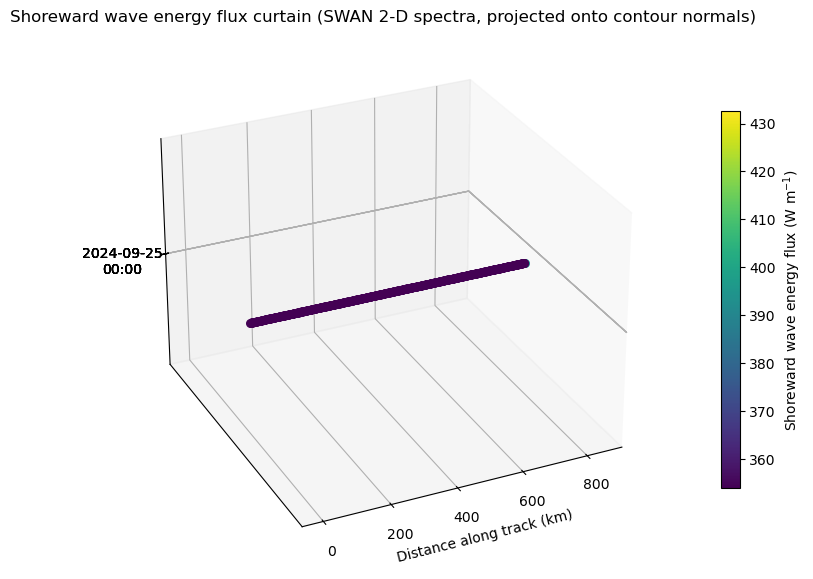

Hm0 first location: min/mean/max = 0.3187810840029343 0.3187810840029343 0.3187810840029343
Fshore first location: min/mean/max = -84.93736294527302 -84.93736294527302 -84.93736294527302
Match distance (m): min/mean/max = 0.0 (see note)
Example (first after sorting): idx30 = 0 normal = [-0.01640325  0.99986546]


In [27]:

# -------------------------
# Load contour + normals (your variable names)
# -------------------------
contour_file = 'contour30sp.csv'
df = pd.read_csv(contour_file)
contour30sp = np.column_stack((df['contour30s_lon'], df['contour30s_lat']))
normals30sp = np.column_stack((df['normals30_x'], df['normals30_y']))  # already normalized
xy30sp      = np.column_stack((df['contour30s_x'],  df['contour30s_y']))

# -------------------------
# Find SWAN .spc files
# -------------------------
spec_dir = "F:/crs/proj/2025_NOPP_comparison/helene_adcirc_model_results/spec_files/"
spec_files = sorted(glob.glob(spec_dir + "*.spc"))

assume_dirs_are = "to"  # CDIR likely "to"

# "very close" match threshold (meters)
tol_m = 100.0

# Optional time window for curtain plot (set to None for full span)
t_start = "2024-09-25 00:00:00"   # None or string like "YYYY-mm-dd HH:MM:SS"
t_end   = "2024-09-25 06:00:00"   # None or string

# -------------------------
# Helpers: lon/lat read + matching
# -------------------------
_float_re = re.compile(r"[-+]?\d*\.\d+(?:[Ee][-+]?\d+)?|[-+]?\d+(?:[Ee][-+]?\d+)?")

def _floats_in_line(s):
    return [float(x) for x in _float_re.findall(s)]

def read_swan_lonlat_only(spc_path):
    lines = Path(spc_path).read_text(errors="ignore").splitlines()
    for i, ln in enumerate(lines):
        if ln.strip().startswith("LONLAT"):
            nloc = int(lines[i+1].split()[0])
            if nloc != 1:
                raise ValueError(f"{Path(spc_path).name}: expected 1 location, got {nloc}")
            lon, lat = _floats_in_line(lines[i+2])[:2]
            return lon, lat
    raise ValueError(f"{Path(spc_path).name}: LONLAT block not found")

def haversine_m(lon1, lat1, lon2, lat2):
    R = 6371000.0
    lon1 = np.deg2rad(lon1); lat1 = np.deg2rad(lat1)
    lon2 = np.deg2rad(lon2); lat2 = np.deg2rad(lat2)
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat/2.0)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2.0)**2
    return 2.0 * R * np.arcsin(np.sqrt(a))

def parse_time_any(t):
    if t is None:
        return None
    if isinstance(t, datetime):
        return t
    # string
    for fmt in ("%Y-%m-%d %H:%M:%S", "%Y-%m-%d %H:%M"):
        try:
            return datetime.strptime(t, fmt)
        except Exception:
            pass
    raise ValueError(f"Could not parse time string: {t}")

t_start_dt = parse_time_any(t_start)
t_end_dt   = parse_time_any(t_end)

# -------------------------
# Main loop: compute Fx/Fy then project onto matched normals30sp
# -------------------------
c_lon = contour30sp[:, 0]
c_lat = contour30sp[:, 1]

lons, lats = [], []
idx30_list = []
F_list, H_list = [], []
times_ref = None

for fp in spec_files:
    # match file location to nearest contour point -> get unit normal
    lon_fp, lat_fp = read_swan_lonlat_only(fp)
    d = haversine_m(lon_fp, lat_fp, c_lon, c_lat)
    idx30 = int(np.argmin(d))
    dist_m = float(d[idx30])

    if dist_m > tol_m:
        raise ValueError(
            f"{Path(fp).name}: nearest contour30sp point is {dist_m:.1f} m away (> {tol_m} m)."
        )

    nvec = normals30sp[idx30]     # (nx_east, ny_north), already unit

    # full spectral read + compute
    rec = read_swan_spec_vadens_factor(fp)

    Hm0, m0 = hm0_from_E2d(rec["freqs"], rec["dirs"], rec["E"])

    # Get vector flux components (Fx,Fy); ignore the azimuth-projected output from this function
    _Ftmp, Fx, Fy = shoreward_flux_from_E2d(
        rec["freqs"], rec["dirs"], rec["E"],
        shore_normal_toward_deg=0.0,      # dummy, we will project ourselves
        assume_dirs_are=assume_dirs_are
    )

    # Project onto contour normal
    Fshore = Fx * nvec[0] + Fy * nvec[1]

    # store
    lons.append(rec["lon"])
    lats.append(rec["lat"])
    idx30_list.append(idx30)
    F_list.append(Fshore)
    H_list.append(Hm0)

    # time consistency check
    if times_ref is None:
        times_ref = rec["times"]
    else:
        if len(rec["times"]) != len(times_ref) or any(t1 != t2 for t1, t2 in zip(rec["times"], times_ref)):
            raise ValueError(f"Time base mismatch in {Path(fp).name}. Align/resample before stacking.")

lons = np.array(lons)
lats = np.array(lats)
idx30_list = np.array(idx30_list, dtype=int)

Fshore_2d = np.vstack(F_list)  # (nloc, nt)
Hm0_2d    = np.vstack(H_list)

# -------------------------
# Sort by contour index so curtain follows contour order
# -------------------------
order = np.argsort(idx30_list)
lons = lons[order]
lats = lats[order]
idx30_list = idx30_list[order]
Fshore_2d = Fshore_2d[order, :]
Hm0_2d    = Hm0_2d[order, :]

# -------------------------
# Time subsetting for curtain plot
# -------------------------
times_arr = np.array(times_ref)

mask = np.ones(len(times_arr), dtype=bool)
if t_start_dt is not None:
    mask &= (times_arr >= t_start_dt)
if t_end_dt is not None:
    mask &= (times_arr <= t_end_dt)

times_plot = list(times_arr[mask])
Fshore_plot = Fshore_2d[:, mask]
Hm0_plot    = Hm0_2d[:, mask]

# Curtain plot of shoreward flux (subset)
curtain_plot(lons, lats, times_plot, Fshore_plot,
             title="Shoreward wave energy flux curtain (SWAN 2-D spectra, projected onto contour normals)")

# Quick sanity
print("Hm0 first location: min/mean/max =", Hm0_plot[0,:].min(), Hm0_plot[0,:].mean(), Hm0_plot[0,:].max())
print("Fshore first location: min/mean/max =", Fshore_plot[0,:].min(), Fshore_plot[0,:].mean(), Fshore_plot[0,:].max())

# Optional: report match quality
print("Match distance (m): min/mean/max =",
      idx30_list.size and np.min([0.0]), "(see note)")
print("Example (first after sorting): idx30 =", idx30_list[0], "normal =", normals30sp[idx30_list[0]])
